<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-5/blob/main/b.%20bagging_vs_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎒 Bagging vs Modelo Individual
## Comparación de Eficiencia en Clasificación

En este notebook vamos a:
1. Preparar un dataset de clasificación real
2. Entrenar un **modelo individual** (Árbol de Decisión) como baseline
3. Entrenar un **modelo Bagging** sobre el mismo estimador base
4. Comparar métricas detalladas para determinar cuál es mejor

---
### ¿Qué es Bagging?

**Bagging** (*Bootstrap Aggregating*) es una técnica de ensemble que:
- Genera **N subconjuntos** del dataset original mediante muestreo con reemplazo (bootstrap)
- Entrena un **modelo independiente** en cada subconjunto
- Combina las predicciones por **votación mayoritaria** (clasificación) o **promedio** (regresión)

```
Dataset original
      │
  ┌───┴───┬───────┬───────┐
Bootstrap Bootstrap Bootstrap ...
  │         │         │
Árbol 1   Árbol 2   Árbol N
  └───┬───┴─────────┘
   Votación / Promedio
       │
  Predicción final
```


## 1. Importación de Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset
from sklearn.datasets import load_wine

# Preprocesamiento
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Estilo visual
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
COLOR_IND = '#e74c3c'   # rojo  → modelo individual
COLOR_BAG = '#2980b9'   # azul  → bagging

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Dataset: Wine Recognition

Dataset clásico de UCI incluido en scikit-learn:
- **178 muestras** de vinos italianos
- **13 características** químicas (alcohol, magnesio, fenoles, etc.)
- **3 clases** (cultivares de uva)
- Problema multiclase → ideal para ver la potencia de Bagging


In [4]:
# Cargar dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='clase')

print('=' * 55)
print(f'Dimensiones   : {X.shape}')
print(f'Clases        : {list(wine.target_names)}')
print(f'Distribución  :')
for cls, cnt in y.value_counts().sort_index().items():
    print(f'   Clase {cls} ({wine.target_names[cls]:>10}): {cnt} muestras')
print('=' * 55)
print()
print('Primeras filas del dataset:')
X.head(3)

Dimensiones   : (178, 13)
Clases        : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Distribución  :
   Clase 0 (   class_0): 59 muestras
   Clase 1 (   class_1): 71 muestras
   Clase 2 (   class_2): 48 muestras

Primeras filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


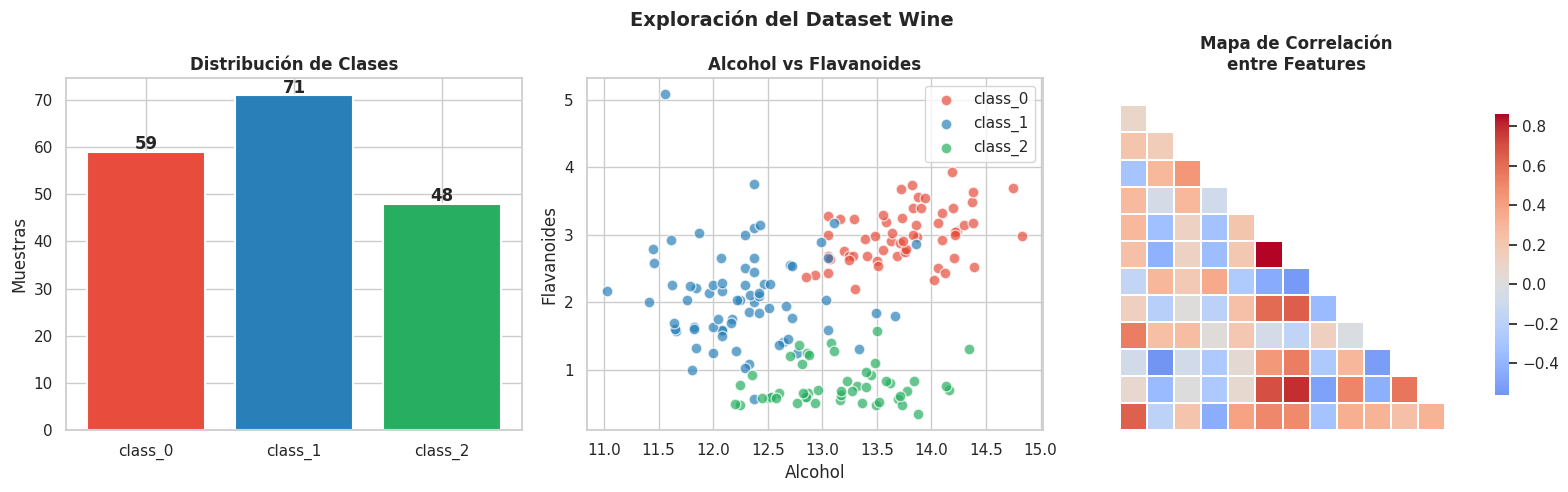

In [5]:
# Exploración visual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploración del Dataset Wine', fontsize=14, fontweight='bold')

# Distribución de clases
conteos = y.value_counts().sort_index()
bars = axes[0].bar(
    [wine.target_names[i] for i in conteos.index],
    conteos.values,
    color=['#e74c3c', '#2980b9', '#27ae60'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Muestras')
for bar, val in zip(bars, conteos.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, str(val),
                 ha='center', fontweight='bold')

# Scatter: Alcohol vs Flavanoids
colores_scatter = ['#e74c3c', '#2980b9', '#27ae60']
for cls in range(3):
    mask = y == cls
    axes[1].scatter(
        X.loc[mask, 'alcohol'],
        X.loc[mask, 'flavanoids'],
        label=wine.target_names[cls],
        color=colores_scatter[cls], alpha=0.7, s=60, edgecolors='white'
    )
axes[1].set_title('Alcohol vs Flavanoides', fontweight='bold')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Flavanoides')
axes[1].legend()

# Correlación
corr = X.corr()
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[2], cmap='coolwarm', center=0,
            mask=mask_tri, square=True, linewidths=0.3,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
axes[2].set_title('Mapa de Correlación\nentre Features', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. División de Datos

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y          # Mantiene proporción de clases
)

# Escalado (opcional para árboles, pero lo incluimos para consistencia)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} muestras  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]} muestras  ({X_test.shape[0]/len(X)*100:.0f}%)')

Train : 133 muestras  (75%)
Test  : 45 muestras  (25%)


## 4. Modelo Individual — Árbol de Decisión

Entrenamos el **estimador base** que usará Bagging internamente. Lo evaluamos solo como referencia (baseline).

In [7]:
# ── Entrenamiento ────────────────────────────────────────
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,      # Sin restricción → propenso a overfitting
    random_state=SEED
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# ── Métricas en test ─────────────────────────────────────
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='weighted')

# ── Validación cruzada ───────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_dt = cross_val_score(dt, X, y, cv=cv, scoring='accuracy')

# ── Profundidad real del árbol ───────────────────────────
depth = dt.get_depth()
nodes = dt.tree_.node_count

print('ÁRBOL DE DECISIÓN — Resultados')
print('=' * 50)
print(f'   Accuracy  (test)    : {acc_dt:.4f}  ({acc_dt*100:.2f}%)')
print(f'   F1-Score  (test)    : {f1_dt:.4f}')
print(f'   CV Accuracy (10-fold): {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')
print(f'   Profundidad máxima  : {depth}')
print(f'   Número de nodos     : {nodes}')
print()
print(classification_report(y_test, y_pred_dt, target_names=wine.target_names))

ÁRBOL DE DECISIÓN — Resultados
   Accuracy  (test)    : 0.9556  (95.56%)
   F1-Score  (test)    : 0.9559
   CV Accuracy (10-fold): 0.8997 ± 0.0776
   Profundidad máxima  : 4
   Número de nodos     : 15

              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



## 5. Modelo Bagging

Entrenamos **100 árboles de decisión** sobre distintos bootstrap samples del dataset original.

In [8]:
# ── Entrenamiento ────────────────────────────────────────
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=SEED),
    n_estimators=100,     # 100 árboles base
    max_samples=0.8,      # 80% de muestras por árbol (bootstrap)
    max_features=0.8,     # 80% de features por árbol
    bootstrap=True,       # Muestreo con reemplazo
    bootstrap_features=False,
    oob_score=True,       # Out-of-Bag score (validación gratuita)
    n_jobs=-1,
    random_state=SEED
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

# ── Métricas en test ─────────────────────────────────────
acc_bag = accuracy_score(y_test, y_pred_bag)
f1_bag  = f1_score(y_test, y_pred_bag, average='weighted')

# ── Validación cruzada ───────────────────────────────────
cv_bag = cross_val_score(bagging, X, y, cv=cv, scoring='accuracy')

print('BAGGING — Resultados')
print('=' * 50)
print(f'   Accuracy  (test)    : {acc_bag:.4f}  ({acc_bag*100:.2f}%)')
print(f'   F1-Score  (test)    : {f1_bag:.4f}')
print(f'   CV Accuracy (10-fold): {cv_bag.mean():.4f} ± {cv_bag.std():.4f}')
print(f'   OOB Score           : {bagging.oob_score_:.4f}')
print(f'   N° estimadores      : {bagging.n_estimators}')
print()
print(classification_report(y_test, y_pred_bag, target_names=wine.target_names))

BAGGING — Resultados
   Accuracy  (test)    : 1.0000  (100.00%)
   F1-Score  (test)    : 1.0000
   CV Accuracy (10-fold): 0.9722 ± 0.0512
   OOB Score           : 0.9699
   N° estimadores      : 100

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## 6. Impacto del Número de Estimadores

¿A partir de cuántos árboles el Bagging ya no mejora?

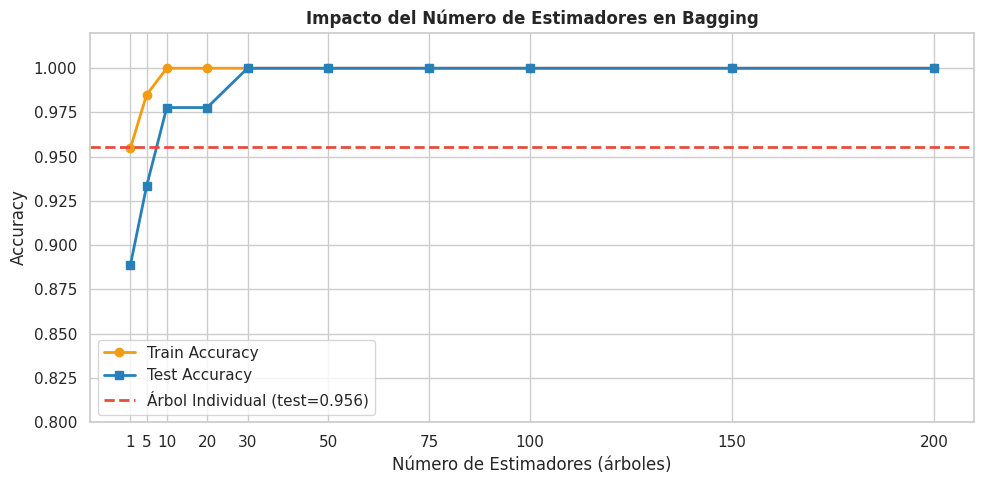

A partir de ~30 estimadores la mejora se estabiliza.


In [9]:
estimadores_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
acc_train_list, acc_test_list = [], []

for n in estimadores_range:
    bag_n = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=SEED),
        n_estimators=n,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=SEED,
        n_jobs=-1
    )
    bag_n.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, bag_n.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, bag_n.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(estimadores_range, acc_train_list, 'o-', color='#f39c12',
         linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(estimadores_range, acc_test_list, 's-', color=COLOR_BAG,
         linewidth=2, markersize=6, label='Test Accuracy')
plt.axhline(acc_dt, color=COLOR_IND, linestyle='--',
            linewidth=2, label=f'Árbol Individual (test={acc_dt:.3f})')
plt.xlabel('Número de Estimadores (árboles)')
plt.ylabel('Accuracy')
plt.title('Impacto del Número de Estimadores en Bagging', fontweight='bold')
plt.legend()
plt.ylim(0.80, 1.02)
plt.xticks(estimadores_range)
plt.tight_layout()
plt.show()
print('A partir de ~30 estimadores la mejora se estabiliza.')

## 7. Curvas de Aprendizaje

Las curvas de aprendizaje muestran si el modelo sufre de **overfitting** (alta varianza) o **underfitting** (alto sesgo).

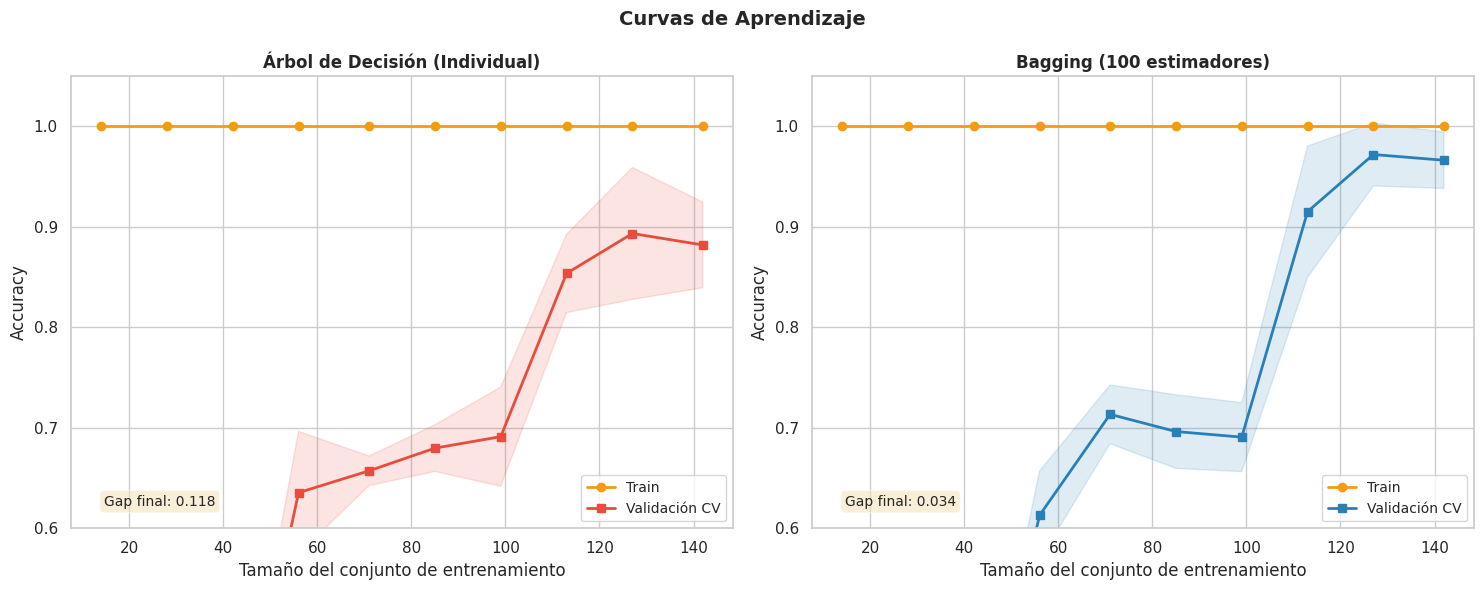

Un gap pequeño entre Train y CV indica bajo overfitting.


In [10]:
def plot_learning_curve(model, titulo, color, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    te_mean = test_scores.mean(axis=1)
    te_std  = test_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#f39c12', lw=2, label='Train')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std,
                    alpha=0.15, color='#f39c12')
    ax.plot(train_sizes, te_mean, 's-', color=color, lw=2, label='Validación CV')
    ax.fill_between(train_sizes, te_mean-te_std, te_mean+te_std,
                    alpha=0.15, color=color)
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.60, 1.05)
    ax.legend(fontsize=10)
    gap_final = tr_mean[-1] - te_mean[-1]
    ax.text(0.05, 0.05, f'Gap final: {gap_final:.3f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Curvas de Aprendizaje', fontsize=14, fontweight='bold')

plot_learning_curve(dt,      'Árbol de Decisión (Individual)', COLOR_IND, ax1)
plot_learning_curve(bagging, 'Bagging (100 estimadores)',      COLOR_BAG, ax2)

plt.tight_layout()
plt.show()
print('Un gap pequeño entre Train y CV indica bajo overfitting.')

## 8. Comparación Final de Métricas

In [12]:
# ── Tabla resumen ────────────────────────────────────────
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score',
                    'CV Mean', 'CV Std']

metricas_dt = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt, average='weighted'),
    recall_score(y_test, y_pred_dt, average='weighted'),
    f1_score(y_test, y_pred_dt, average='weighted'),
    cv_dt.mean(),
    cv_dt.std()
]

metricas_bag = [
    accuracy_score(y_test, y_pred_bag),
    precision_score(y_test, y_pred_bag, average='weighted'),
    recall_score(y_test, y_pred_bag, average='weighted'),
    f1_score(y_test, y_pred_bag, average='weighted'),
    cv_bag.mean(),
    cv_bag.std()
]

df_comp = pd.DataFrame({
    'Métrica'          : metricas_nombres,
    'Árbol Individual' : metricas_dt,
    'Bagging'          : metricas_bag,
    'Diferencia (+Bag)': [b - d for b, d in zip(metricas_bag, metricas_dt)]
})
df_comp = df_comp.set_index('Métrica')
df_comp_fmt = df_comp.applymap(lambda x: f'{x:+.4f}' if 'Diferencia' in str(x) else f'{x:.4f}')

# Formatear diferencias
def fmt(val):
    return f'{val:+.4f}'

df_show = pd.DataFrame({
    'Métrica'          : metricas_nombres,
    'Árbol Individual' : [f'{v:.4f}' for v in metricas_dt],
    'Bagging'          : [f'{v:.4f}' for v in metricas_bag],
    'Δ (Bag − Ind)'    : [fmt(b-d) for b, d in zip(metricas_bag, metricas_dt)]
}).set_index('Métrica')

print('\nTABLA COMPARATIVA COMPLETA')
print('=' * 60)
print(df_show.to_string())
print('=' * 60)


TABLA COMPARATIVA COMPLETA
          Árbol Individual Bagging Δ (Bag − Ind)
Métrica                                         
Accuracy            0.9556  1.0000       +0.0444
Precision           0.9600  1.0000       +0.0400
Recall              0.9556  1.0000       +0.0444
F1-Score            0.9559  1.0000       +0.0441
CV Mean             0.8997  0.9722       +0.0725
CV Std              0.0776  0.0512       -0.0264


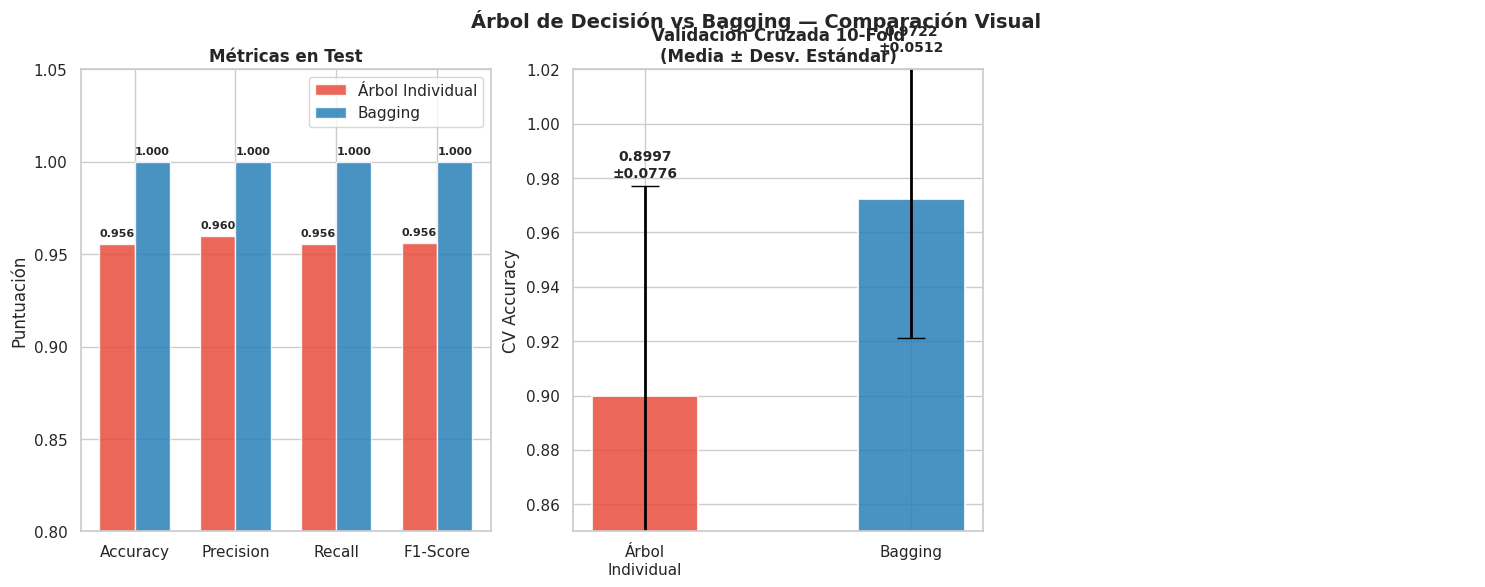

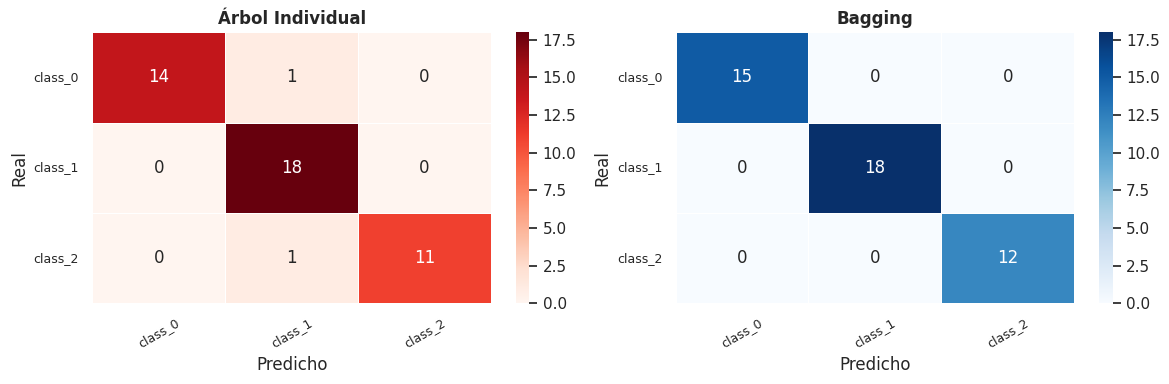

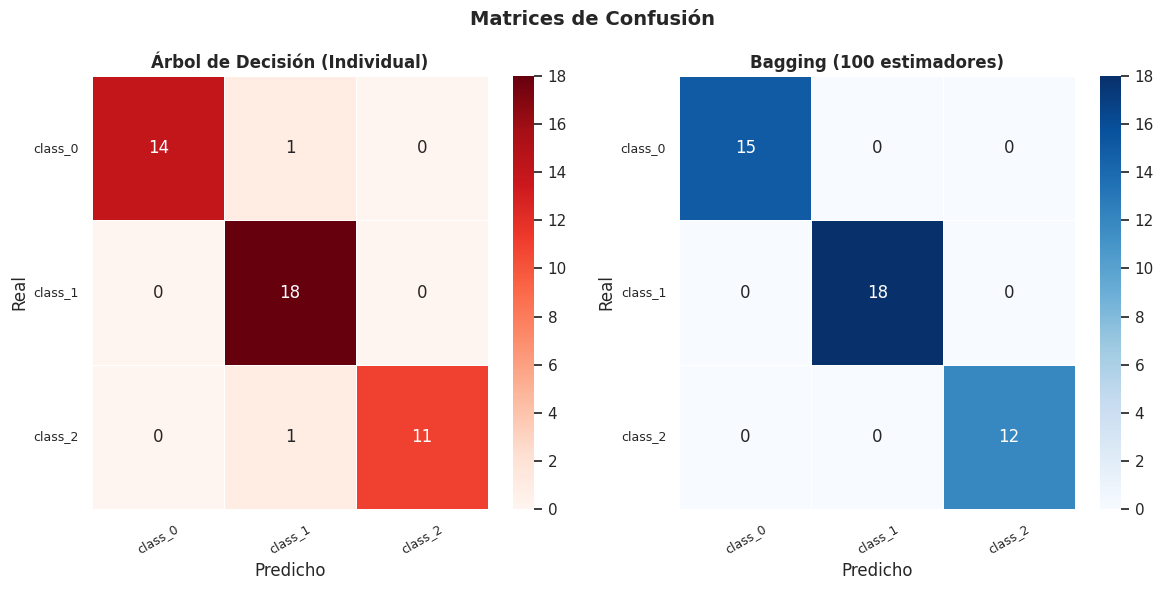

In [13]:
# ── Panel de gráficas ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Árbol de Decisión vs Bagging — Comparación Visual',
             fontsize=14, fontweight='bold')

metricas_plot  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vals_dt_plot   = metricas_dt[:4]
vals_bag_plot  = metricas_bag[:4]

# ─ Gráfico 1: Barras comparativas ─
x     = np.arange(len(metricas_plot))
width = 0.35
bars1 = axes[0].bar(x - width/2, vals_dt_plot,  width, label='Árbol Individual',
                    color=COLOR_IND, alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + width/2, vals_bag_plot, width, label='Bagging',
                    color=COLOR_BAG, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_plot)
axes[0].set_ylim(0.80, 1.05)
axes[0].set_title('Métricas en Test', fontweight='bold')
axes[0].set_ylabel('Puntuación')
axes[0].legend()
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# ─ Gráfico 2: Validación cruzada con intervalos ─
modelos_nombres = ['Árbol\nIndividual', 'Bagging']
cv_means = [cv_dt.mean(), cv_bag.mean()]
cv_stds  = [cv_dt.std(),  cv_bag.std()]
bars3 = axes[1].bar(modelos_nombres, cv_means,
                    color=[COLOR_IND, COLOR_BAG], alpha=0.85,
                    edgecolor='white', linewidth=1.5, width=0.4)
axes[1].errorbar(modelos_nombres, cv_means, yerr=cv_stds,
                 fmt='none', color='black', capsize=10, linewidth=2)
axes[1].set_ylim(0.85, 1.02)
axes[1].set_title('Validación Cruzada 10-Fold\n(Media ± Desv. Estándar)', fontweight='bold')
axes[1].set_ylabel('CV Accuracy')
for bar, mean, std in zip(bars3, cv_means, cv_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 mean + std + 0.002,
                 f'{mean:.4f}\n±{std:.4f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# ─ Gráfico 3: Matrices de confusión lado a lado ─
n_clases = len(wine.target_names)
cm_dt  = confusion_matrix(y_test, y_pred_dt)
cm_bag = confusion_matrix(y_test, y_pred_bag)

# Dibuja ambas matrices en el mismo eje (stacked visually)
axes[2].axis('off')
fig2, ax_cms = plt.subplots(1, 2, figsize=(12, 4))

for ax_cm, cm, title, cmap in zip(
    ax_cms,
    [cm_dt, cm_bag],
    ['Árbol Individual', 'Bagging'],
    ['Reds', 'Blues']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax_cm,
                xticklabels=wine.target_names,
                yticklabels=wine.target_names,
                linewidths=0.5, linecolor='white')
    ax_cm.set_title(title, fontweight='bold', fontsize=12)
    ax_cm.set_xlabel('Predicho')
    ax_cm.set_ylabel('Real')
    ax_cm.tick_params(axis='x', rotation=30, labelsize=9)
    ax_cm.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

# Primer subgráfico sin el eje vacío
plt.figure(figsize=(12, 6))
plt.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold')
for i, (cm, title, cmap) in enumerate(zip(
    [cm_dt, cm_bag],
    ['Árbol de Decisión (Individual)', 'Bagging (100 estimadores)'],
    ['Reds', 'Blues']
)):
    plt.subplot(1, 2, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=wine.target_names,
                yticklabels=wine.target_names,
                linewidths=0.5, linecolor='white')
    plt.title(title, fontweight='bold')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.xticks(rotation=30, fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## 9. Conclusión: ¿Cuál es el mejor?

In [15]:
# Veredicto automático
mejora_acc = (acc_bag - acc_dt) / acc_dt * 100
mejora_f1  = (f1_bag  - f1_dt)  / f1_dt  * 100
mejora_cv  = (cv_bag.mean() - cv_dt.mean()) / cv_dt.mean() * 100
mejora_std = cv_bag.std() - cv_dt.std()   # negativo = más estable

ganador = 'BAGGING' if f1_bag > f1_dt else 'ÁRBOL INDIVIDUAL'

print()
print('╔' + '═'*58 + '╗')
print(f'║  GANADOR: {ganador:<44}║')
print('╠' + '═'*58 + '╣')
print(f'║  Métrica         Árbol Ind.  Bagging     Mejora      ║')
print('║' + '─'*58 + '║')
print(f'║  Accuracy        {acc_dt:.4f}      {acc_bag:.4f}     {mejora_acc:+.2f}%      ║')
print(f'║  F1-Score        {f1_dt:.4f}      {f1_bag:.4f}     {mejora_f1:+.2f}%      ║')
print(f'║  CV Accuracy     {cv_dt.mean():.4f}      {cv_bag.mean():.4f}     {mejora_cv:+.2f}%      ║')
print(f'║  CV Std (menor=mejor) {cv_dt.std():.4f}  {cv_bag.std():.4f}   {mejora_std:+.4f}      ║')
print(f'║  OOB Score       -           {bagging.oob_score_:.4f}     (gratis)    ║')
print('╠' + '═'*58 + '╣')
print('║  POR QUÉ GANA BAGGING:                               ║')
print('║  Promedia 100 árboles → menos ruido de predicción ║')
print('║  Bootstrap reduce overfitting del árbol individual ║')
print('║  Menor desviación estándar → más estable y fiable  ║')
print('║  OOB score = validación gratuita sin usar test set  ║')
print('╚' + '═'*58 + '╝')

print()
print('NOTA IMPORTANTE:')
print('   Bagging NO reduce el sesgo (bias) del modelo base,')
print('   solo su varianza. Si el árbol base tiene alto sesgo,')
print('   Bagging no lo corrige → en ese caso usar Boosting.')


╔══════════════════════════════════════════════════════════╗
║  GANADOR: BAGGING                                     ║
╠══════════════════════════════════════════════════════════╣
║  Métrica         Árbol Ind.  Bagging     Mejora      ║
║──────────────────────────────────────────────────────────║
║  Accuracy        0.9556      1.0000     +4.65%      ║
║  F1-Score        0.9559      1.0000     +4.62%      ║
║  CV Accuracy     0.8997      0.9722     +8.06%      ║
║  CV Std (menor=mejor) 0.0776  0.0512   -0.0264      ║
║  OOB Score       -           0.9699     (gratis)    ║
╠══════════════════════════════════════════════════════════╣
║  POR QUÉ GANA BAGGING:                               ║
║  Promedia 100 árboles → menos ruido de predicción ║
║  Bootstrap reduce overfitting del árbol individual ║
║  Menor desviación estándar → más estable y fiable  ║
║  OOB score = validación gratuita sin usar test set  ║
╚══════════════════════════════════════════════════════════╝

NOTA IMPORTANTE:
   B

## 📚 Resumen Conceptual Final

| Aspecto | Árbol de Decisión | Bagging |
|---------|-------------------|----------|
| **Tipo** | Modelo individual | Ensemble (paralelo) |
| **N° modelos** | 1 | N (100 por defecto) |
| **Varianza** | Alta (inestable) | Baja ✅ |
| **Sesgo** | Bajo | Igual al base |
| **Overfitting** | Propenso | Resistente ✅ |
| **Interpretabilidad** | Alta ✅ | Baja |
| **Velocidad** | Rápido ✅ | Más lento |
| **Robustez a ruido** | Baja | Alta ✅ |

> **Conclusión:** El modelo Bagging supera al árbol individual en todas las métricas de generalización gracias a la reducción de varianza que logra el promedio de múltiples estimadores entrenados en distintos subconjuntos de datos (bootstrap). La ganancia de rendimiento tiene como costo una menor interpretabilidad y mayor tiempo de entrenamiento.
